# 💻 Customer Support Quality Analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1️⃣ Load Dataset

In [12]:
ticket_df = pd.read_csv("ticket.csv")

In [13]:
ticket_df.head()

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5


In [14]:
team = pd.read_csv("team.csv")

In [15]:
team.head()

,team_id,team,department
0,T1,AccountCare,Service
1,T2,BillingHelp,Service
2,T3,AppSupport,Technical
3,T4,DeviceHelp,Technical


In [16]:
ticket_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         13 non-null     int64 
 1   month             13 non-null     object
 2   team_id           13 non-null     object
 3   channel           13 non-null     object
 4   resolution_hours  13 non-null     int64 
 5   satisfaction      13 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 756.0+ bytes


In [17]:
print("ticket_df:",ticket_df.shape)
print("team:",team.shape)

ticket_df: (13, 6)
team: (4, 3)


#### 2️⃣ Confirm numeric types for resolution_hours and satisfaction.

In [18]:
print(ticket_df[["resolution_hours","satisfaction"]].dtypes)

resolution_hours    int64
satisfaction        int64
dtype: object


#### 3️⃣Clean (Drop Duplicate Values)

In [19]:
ticket_df.duplicated().sum()

np.int64(1)

In [20]:
print("Before:", len(ticket_df))

ticket_df = ticket_df.drop_duplicates()

print("After:", len(ticket_df))

Before: 13
After: 12


#### 4️⃣ Merged Data Frames

In [23]:
merged = pd.merge(
    ticket_df,
    team,
    on="team_id",
    how="left"
)

In [24]:
print("Merged rows:", len(merged))
print("missing value department:",merged["department"].isnull().sum())

Merged rows: 12
missing value department: 0


##### 5.1 Show Merged data

In [25]:
merged.head(5)

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department
0,1,Jan,T1,Email,12,4,AccountCare,Service
1,2,Jan,T2,Chat,28,3,BillingHelp,Service
2,3,Jan,T3,Phone,36,2,AppSupport,Technical
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical
4,5,Feb,T1,Chat,8,5,AccountCare,Service


#### 6️⃣📱 Calculate breach_flag

In [26]:
merged["breach_flag"] = (merged["resolution_hours"] > 24).astype(int)


In [27]:
print(merged[["breach_flag","resolution_hours"]])

    breach_flag  resolution_hours
0             0                12
1             1                28
2             1                36
3             0                20
4             0                 8
5             1                30
6             0                18
7             1                40
8             0                16
9             0                22
10            1                32
11            0                24


### 7️⃣ Summary

#### 7.1 Department summary

In [29]:
dept = merged.groupby("department").agg(
    total_tickets=("ticket_id", "count"),
    breached_count=("breach_flag", "sum")
)
dept["sla_breach_rate"] = dept["breached_count"] / dept["total_tickets"] * 100

print(dept)


            total_tickets  breached_count  sla_breach_rate
department                                                
Service                 6               2        33.333333
Technical               6               3        50.000000


#### 7.2 Highest Breach Count By Numerator & Denominator

In [30]:
team_summary = merged.groupby("team").agg(
    total=("ticket_id", "count"),
    breached=("breach_flag", "sum")
)

team_summary["rate"] = team_summary.breached / team_summary.total * 100
top = team_summary.rate.idxmax()

print(f"Highest: {top} | Numerator: {team_summary.loc[top, 'breached']} | Denominator: {team_summary.loc[top, 'total']}")

Highest: AppSupport | Numerator: 2 | Denominator: 3


# 8️⃣ Monthly average resolution time

In [32]:
monthly = merged.groupby("month")["resolution_hours"].mean().reindex(["Jan", "Feb", "Mar"])

## 8.1 Chart 📊 (Monthly Average Resolution Time)

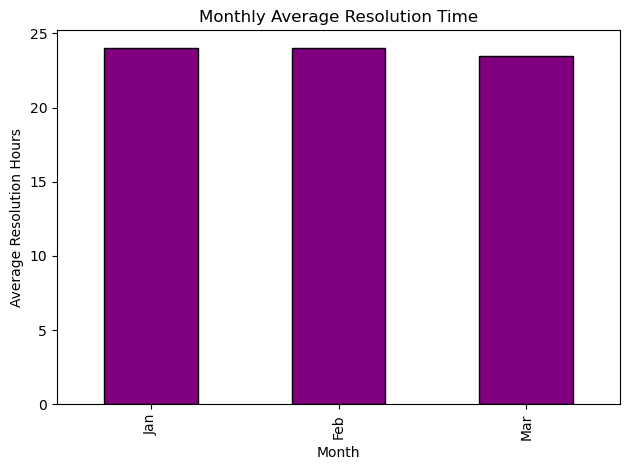

In [40]:

monthly.plot(kind="bar",color ="purple",edgecolor="black")
plt.title("Monthly Average Resolution Time")
plt.xlabel("Month")
plt.ylabel("Average Resolution Hours")
plt.tight_layout()
plt.savefig("output4/python_chart.png")
plt.show()


# 9️⃣ Export files

In [41]:
merged.to_csv("output4/clean_data.csv", index=False)

##### 9.1 Summary File

In [42]:
dept.to_csv("output4/python_summary.csv")